In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

medical_data = pd.read_csv('insurance.csv')
# print(medical_data)
# print(medical_data.info())
print(medical_data.smoker.value_counts())

# fig = px.histogram(medical_data, x = 'age', marginal = 'box', nbins = 47, title = 'Distribution of Age')

# fig = px.histogram(medical_data,
             #      x = 'sex',
             #      marginal = 'box',
             #      color = 'region',
             #      color_discrete_sequence = ['green', 'grey'],
             #      title = 'Distribution of Charges')

#fig.update_layout(bargap = 0.1)
# fig.show()

px.histogram(medical_data, x = 'sex', title = 'Sex')
px.histogram(medical_data, x = 'region', color = 'smoker', title = 'Region')
px.histogram(medical_data, x = 'children', color = 'smoker' , title = 'Children')


fig = px.scatter(medical_data, x = 'age', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Age vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'bmi', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'BMI vs Charges')
fig.update_traces(marker_size = 5)
fig.show()

fig = px.scatter(medical_data, x = 'children', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Children vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'sex', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Sex vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'region', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Region vs Charges')
fig.update_traces(marker_size = 6)
fig.show()

fig = px.scatter(medical_data, x = 'smoker', y = 'charges', opacity = 0.8, hover_data = ['sex'], color = 'smoker', title = 'Smoker vs Charges')
fig.update_traces(marker_size = 6)
fig.show()


medical_data.charges.corr(medical_data.age)
medical_data.charges.corr(medical_data.bmi)
medical_data.charges.corr(medical_data.children)

smoker
no     1064
yes     274
Name: count, dtype: int64


np.float64(0.0679982268479048)

<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

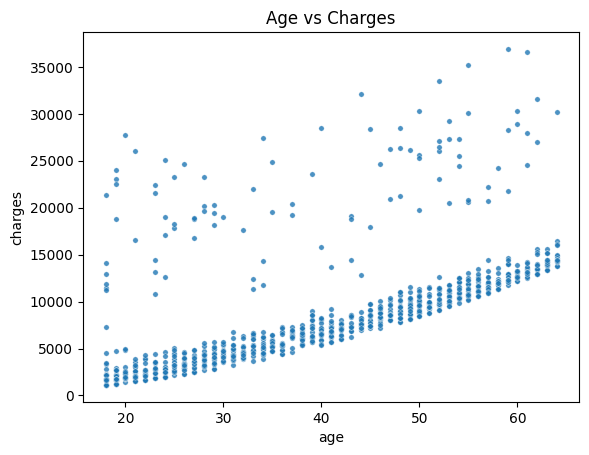

In [11]:
non_smoker = medical_data[medical_data.smoker == 'no']

plt.title('Age vs Charges')
sns.scatterplot(non_smoker, x = 'age', y = 'charges', alpha = 0.8, s = 15)

In [12]:
def estimate_charges(age, m, c):
    return m * age + c

In [18]:
m = 50
c = 100

In [19]:
estimate_charges(40, m, c)

2100

In [23]:
age = non_smoker.age
age

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [25]:
estimated_charges = estimate_charges(age, m, c)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [26]:
non_smoker.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

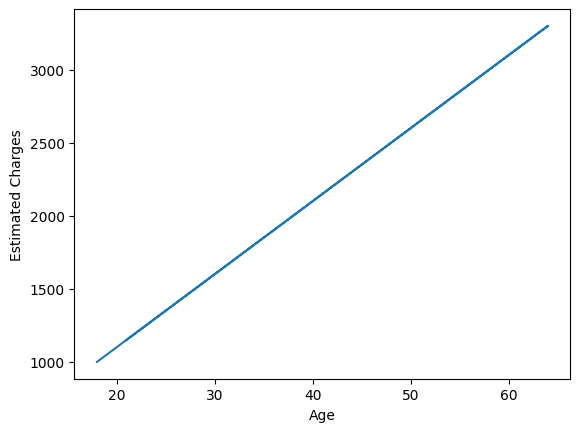

In [28]:
plt.plot(age, estimated_charges);
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

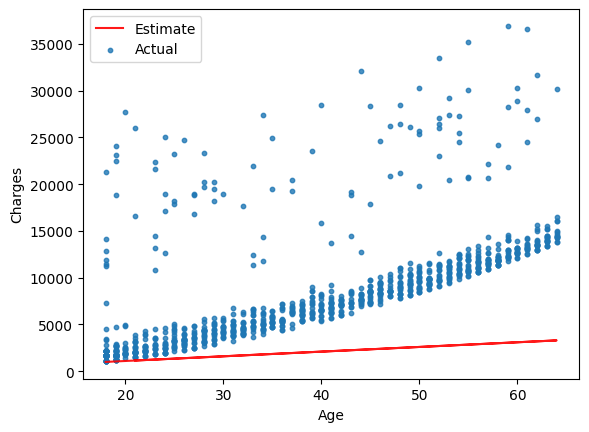

In [33]:
target = non_smoker.charges

plt.plot(age, estimated_charges, 'r', alpha = 0.9);
plt.scatter(age, target, alpha = 0.8, s = 10);
plt.xlabel('Age');
plt.ylabel('Charges');
plt.legend(['Estimate', 'Actual']);

In [34]:
def try_para(m, c):
    age = non_smoker.age
    target = non_smoker.charges

    estimated_charges = estimate_charges(age, m, c)

    plt.plot(age, estimated_charges, 'r', alpha = 0.9);
    plt.scatter(age, target, alpha = 0.8, s = 10);
    plt.xlabel('Age');
    plt.ylabel('Charges');
    plt.legend(['Estimate', 'Actual']);

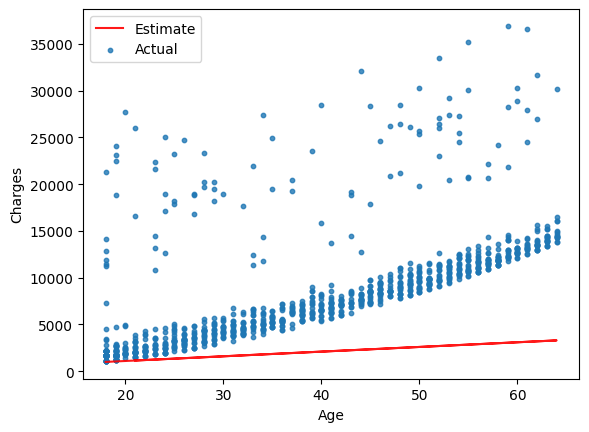

In [35]:
try_para(50, 100)

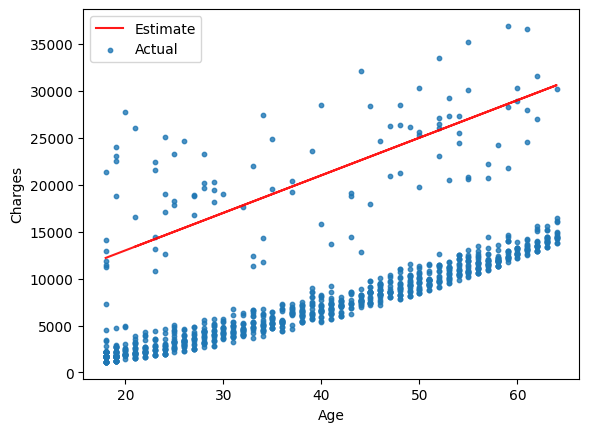

In [36]:
try_para(400, 5000)

In [37]:
import numpy as np


In [38]:
def rmse(target, prediction):
    return np.sqrt(np.mean((target - prediction) ** 2))

In [39]:
m = 50
c = 100

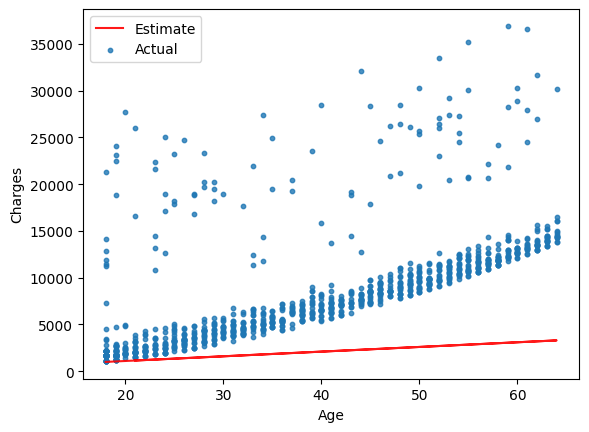

In [40]:
try_para(m, c)

In [41]:
target = non_smoker['charges']
predicted = estimate_charges(non_smoker.age, m, c)

In [42]:
rmse(target, predicted)

np.float64(8461.949562575493)

In [43]:
def try_para(m, c):
    age = non_smoker.age
    target = non_smoker.charges
    predictions = estimate_charges(age, m, c)

    plt.plot(age, predictions, 'r', alpha = 0.9);
    plt.scatter(age, target, alpha = 0.8, s = 10);
    plt.xlabel('Age');
    plt.ylabel('Charges');
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print(f'RMSE LOSS: {loss}')

RMSE LOSS: 4844.628794098396


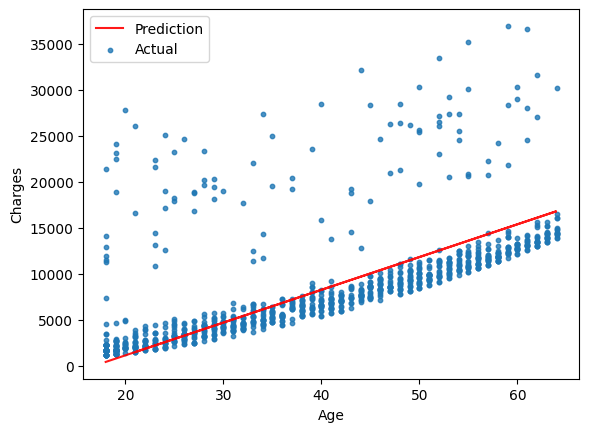

In [122]:
try_para(356, -6000)

In [123]:
!pip3 install scikit-learn --quiet


In [124]:
from sklearn.linear_model import LinearRegression

In [125]:
model = LinearRegression()

In [127]:
inputs = non_smoker[['age']]
targets = non_smoker.charges
print('inputs: ', inputs.shape)
print('targets: ', targets.shape)

inputs:  (1064, 1)
targets:  (1064,)


In [128]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [129]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/Users/harshiljodhani/Harshil-Codes/Harshil-PD/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [131]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [133]:
inputs
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [134]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [135]:
model.coef_ # m

array([267.24891283])

In [136]:
model.intercept_ # c

np.float64(-2091.4205565650773)

RMSE LOSS: 4662.505766636395


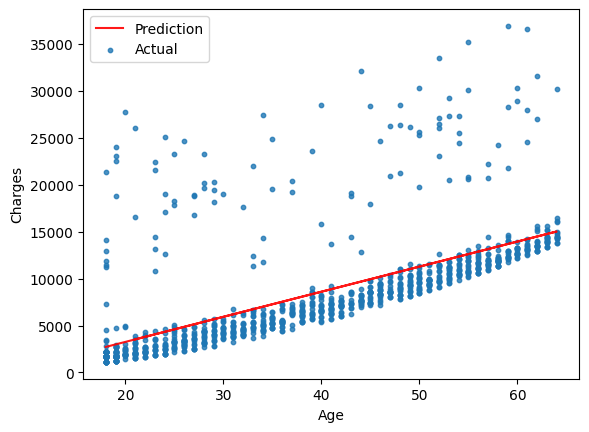

In [137]:
try_para(model.coef_, model.intercept_)